# Trustworthy LLM Confidence for Downstream Decisions with MCGrad

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/facebookincubator/MCGrad/blob/main/tutorials/02_calibrating_llm_outputs.ipynb)

If you're using an LLM as a classifier and you want to act on its confidence (auto-flag, route uncertain cases to humans, estimate prevalence), the score has to behave like a probability. When the model rates an item at 0.9, the chance it's actually positive should be around 90%. That has to hold for every segment of your data (countries, content types, customer cohorts, time periods), so decisions on those segments behave consistently. For example: a 0.9 threshold should mean the same chance of being positive in every segment, not 70% in one country and 95% in another.

Raw LLM confidence rarely satisfies either property. Global calibration methods like isotonic regression fix the on-average picture but not the per-segment one: their corrections are population-wide, so per-segment errors can cancel out at the global level and leave the score scale wrong inside any individual sub-population.

This tutorial shows how to improve raw LLM scores so they're usable for downstream decisions. We use two example applications throughout: setting confidence thresholds for action (§5.1) and per-segment prevalence estimation (§5.2). The method is multi-calibration, applied via the [MCGrad](https://mcgrad.dev) library. The demo data is Claude Opus 4.6 classifying political texts from the [Comparative Agendas Project (CAP)](https://www.comparativeagendas.net/) as related to *Law and Crime*, but the recipe applies to any LLM-as-classifier setup.

## Outline

1. Setup. Load the pre-computed Opus inference outputs, compare raw LLM probabilities to actual rates per country, then split into train/test.

2. Performance, calibration, multicalibration. The LLM's discriminative quality is good, global calibration is off, and per-segment miscalibration survives isotonic regression.

3. MCGrad basics. Fit MCGrad to address the multicalibration error.

4. Model evaluation. Compare base LLM, isotonic regression, and MCGrad on calibration and ranking metrics.

5. Putting the calibrated scores to use. Confidence thresholds you can trust across segments, plus per-segment prevalence estimation.

6. Next steps. Pointers to deeper documentation.

Runs end to end in about 3 minutes on a laptop CPU.

## 1. Setup

MCGrad must be installed. See the [installation guide](https://mcgrad.dev/docs/installation) for additional instructions.

In [1]:
# Run this cell when working in Colab or in a fresh environment.
# %pip install mcgrad

In [2]:
import os
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import metrics as skmetrics
from sklearn.model_selection import train_test_split

import mcgrad
from mcgrad import metrics, methods, plotting

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print(f'MCGrad version: {mcgrad.__version__}')

/Users/flinder/.local/lib/python3.12/site-packages/joblib/_multiprocessing_helpers.py:44: UserWarning: [Errno 1] Operation not permitted.  joblib will operate in serial mode
  warnings.warn("%s.  joblib will operate in serial mode" % (e,))


MCGrad version: 0.1.4.dev3+ga17e89c1b


We reuse a few small helpers from `mcgrad.tutorials.helpers` for plot styling and to format the comparison tables.

In [3]:
from mcgrad.tutorials.helpers import (
    combine_segment_calibration_plots,
    configure_logging,
    format_calibration_metrics_table,
    setup_plotting,
)

setup_plotting()
configure_logging()

### 1.1 Dataset and ML task

We use 30,000 documents from the Comparative Agendas Project, with expert ground-truth labels for whether each document primarily addresses **Law and Crime** (the binary outcome). Each document was classified by Claude Opus 4.6 twice in independent campaigns: once for a binary Yes/No (column `llm_yes`), once for a direct probability estimate of P(Yes) (column `pyn_score`). The probability is our base model output — the score we'll calibrate.

The 30K sample spans six sub-populations across four countries and four languages: Danish parliamentary questions, Spanish parliamentary questions, US congressional bills, Belgian newspaper articles, Spanish online media, and Belgian TV news.

| Column | Description |
|---|---|
| `country`     | Country of origin (Belgium, Denmark, Spain, USA) |
| `doc_type`    | Document type (parliamentary_question, bill, newspaper) |
| `party`       | Political party where applicable (59 unique values) |
| `decade`      | Decade the document was authored (1940s–2010s) |
| `text_len`    | Document length in characters |
| `pyn_score`   | LLM-elicited P(Yes), the base model output |
| `llm_yes`     | LLM Yes/No classification (used for diagnostics) |
| `law_crime`   | Binary ground-truth label |

The data lives in the [multicalibrated_llm_measurement](https://github.com/facebookresearch/multicalibrated_llm_measurement) repo accompanying the paper. The cell below downloads it once and caches locally; re-runs are instant.

In [4]:
import urllib.request
from pathlib import Path

DATA_BASE = (
    'https://raw.githubusercontent.com/facebookresearch/'
    'multicalibrated_llm_measurement/main/cap_analysis/data'
)
CACHE_DIR = Path.home() / '.cache' / 'mcgrad_tutorials' / 'cap_data'

def fetch_cap_file(rel_path: str) -> str:
    """Download a file from the public CAP data repo if not cached."""
    local = CACHE_DIR / rel_path
    if not local.exists():
        local.parent.mkdir(parents=True, exist_ok=True)
        url = f'{DATA_BASE}/{rel_path}'
        print(f'Downloading {rel_path}...')
        urllib.request.urlretrieve(url, local)
    return str(local)

sample = pd.read_csv(fetch_cap_file('opus_30k_sample.csv'))
sample['party'] = sample['party'].fillna('unknown')
sample['text_len'] = sample['text'].str.len()

binary = pd.read_csv(
    fetch_cap_file('inference_output/claude-opus-30k-binary/merged.csv')
).drop_duplicates(subset='id', keep='first')
binary['llm_yes'] = (binary['answer'].str.lower() == 'yes').astype(int)

pyn = pd.read_csv(
    fetch_cap_file('inference_output/claude-opus-30k-pyn/merged.csv')
)

data = sample.merge(binary[['id', 'llm_yes']], on='id', how='left')
data = data.merge(pyn[['id', 'score']], on='id', how='left').rename(columns={'score': 'pyn_score'})
data = data.dropna(subset=['llm_yes'])
data['llm_yes'] = data['llm_yes'].astype(int)

print(f'Total documents: {len(data):,}')
print(f'Sub-populations: {data.subpop.nunique()}')
data[['country', 'doc_type', 'party', 'decade', 'text_len',
      'pyn_score', 'llm_yes', 'law_crime']].head()

Total documents: 29,900
Sub-populations: 6


,country,doc_type,party,decade,text_len,pyn_score,llm_yes,law_crime
0,Belgium,newspaper,unknown,1990,1057,0.02,0,0
1,Belgium,newspaper,unknown,2000,1887,0.05,1,0
2,Belgium,newspaper,unknown,2000,2842,0.03,0,0
3,Belgium,newspaper,unknown,1990,1685,0.35,1,0
5,Belgium,newspaper,unknown,1990,363,0.03,0,0


### 1.2 Do the raw scores already act like probabilities?

The LLM was prompted to estimate `P(Yes)` directly, so if those scores are calibrated, averaging them within any group of documents should give us the actual rate of law/crime in that group. Below, by country, on the full labelled dataset:

In [5]:
preview = data.groupby('country').agg(
    n=('law_crime', 'size'),
    llm_avg_score=('pyn_score', 'mean'),
    actual_rate=('law_crime', 'mean'),
)
preview['gap_pp'] = (preview['llm_avg_score'] - preview['actual_rate']) * 100
preview.style.format({
    'llm_avg_score': '{:.1%}',
    'actual_rate':   '{:.1%}',
    'gap_pp':        '{:+.1f}p',
})

,n,llm_avg_score,actual_rate,gap_pp
country,,,,
Belgium,9900,15.0%,10.0%,+5.0p
Denmark,5000,10.4%,7.3%,+3.1p
Spain,10000,17.0%,15.4%,+1.6p
United States,5000,7.7%,4.8%,+2.9p


**The LLM over-estimates the law/crime rate in every country, by different amounts each time.** The biggest gap is +5pp on Belgium (15.0% predicted vs 10.0% actual); the smallest is +1.6pp on Spain. The over-estimate isn't a fixed offset; it depends on the country.

If you used these scores directly to estimate prevalence per country, your numbers would be wrong by 1.6 to 5pp depending on country. If you used them to threshold for a downstream decision (auto-action, human routing, escalation), the same threshold would give different error tradeoffs in different countries. Getting consistent tradeoffs would require tuning a threshold per segment.

The rest of this notebook addresses that gap. §2 diagnoses where it comes from; §2.3 shows why global calibration only partially fixes it; §3–4 apply MCGrad; §5 puts the calibrated scores to work for downstream decisions.

### 1.3 Train/test split

We split the full dataset into a small training set (used to fit isotonic regression and MCGrad) and a larger test set for evaluation. About 6,000 training documents is enough for MCGrad to fit well here. The split is stratified by sub-population and label, so all six sub-populations and both classes are represented proportionally.

In [6]:
LABEL_COLUMN = 'law_crime'
BASE_SCORE_COLUMN = 'pyn_score'  # LLM-elicited P(Yes) — the 'base model' output

data['_strat'] = data['subpop'] + '_' + data[LABEL_COLUMN].astype(str)
train_df, test_df = train_test_split(
    data, test_size=0.80, random_state=42, stratify=data['_strat'],
)
train_df = train_df.copy()
test_df = test_df.copy()

print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')
print(f'Base rate of Law and Crime: train={train_df[LABEL_COLUMN].mean():.3f}, '
      f'test={test_df[LABEL_COLUMN].mean():.3f}')

Train: 5,980 | Test: 23,920
Base rate of Law and Crime: train=0.105, test=0.105


## 2. Assessing Model Performance, Calibration and Multicalibration

A model is *calibrated* if its predicted probabilities match observed rates: among all predictions of 0.7, roughly 70% should be positive. We evaluate the LLM's predictive performance and calibration on the test set.

### 2.1 Discriminative Performance

The standard ML metrics: area under the precision-recall curve (PRAUC), ROC AUC, and log-loss.

In [7]:
evaluation_metrics = {
    'PRAUC':    skmetrics.average_precision_score,
    'ROCAUC':   skmetrics.roc_auc_score,
    'log_loss': skmetrics.log_loss,
}

perf = {
    name: fn(test_df[LABEL_COLUMN].values, test_df[BASE_SCORE_COLUMN].values)
    for name, fn in evaluation_metrics.items()
}
pd.DataFrame.from_dict(perf, orient='index').rename(columns={0: 'LLM (pyn_score)'}).round(3)

,LLM (pyn_score)
PRAUC,0.853
ROCAUC,0.982
log_loss,0.122


The LLM achieves strong discriminative performance: ROCAUC ~0.98, PRAUC ~0.85. It separates Law and Crime documents from the rest. However, as we saw in §1.2 (per-country prevalence over-estimated by 1.6–5pp), discriminative performance does not imply that the model is well calibrated. The next sections diagnose where the miscalibration comes from.

### 2.2 Global Calibration

The §1.2 preview showed that the LLM's mean confidence per country doesn't match the actual rate. To trace where that gap comes from, we look at the score's calibration directly.

We start with the global picture (calibration averaged over the whole dataset), then drill into per-segment calibration in §2.3. If global calibration is already bad, the score is uniformly mis-scaled and a single global correction can help. If global is fine but per-segment is off, the score is *multi*-miscalibrated: globally OK, but wrong inside sub-populations. Global corrections can't fix that.

The standard diagnostic is the calibration curve: bin predictions, then plot the bucket's average predicted probability against the empirical positive rate inside that bucket. A perfectly calibrated score traces the 45° diagonal.

In [8]:
plotting.plot_global_calibration_curve(
    data=test_df,
    score_col=BASE_SCORE_COLUMN,
    label_col=LABEL_COLUMN,
    num_bins=40,
).update_layout(title='Global Calibration Curve — LLM (pyn_score)', width=1200, height=700)

The curve sits noticeably below the diagonal across most of the score range. The LLM is systematically over-confident: when it says 0.5, the empirical positive rate is closer to 0.4.

We quantify this with the **Estimated Cumulative Calibration Error** ([ECCE](https://arxiv.org/abs/2205.09680)), which doesn't depend on bin count and has a known sampling distribution under perfect calibration. The number of standard deviations away from zero ("sigmas") tells us whether the miscalibration is statistically significant.

In [9]:
def compute_ecce_with_sigma(labels, predictions):
    return metrics.ecce(labels, predictions), metrics.ecce_sigma(labels, predictions)

In [10]:
ecce_base, ecce_sigma_base = compute_ecce_with_sigma(
    test_df[LABEL_COLUMN].values, test_df[BASE_SCORE_COLUMN].values,
)
print(f'Global miscalibration of the LLM:\nECCE: {ecce_base:.4f} ({ecce_sigma_base:.2f} sigmas)')

Global miscalibration of the LLM:
ECCE: 0.0330 (22.27 sigmas)


There is strong statistical evidence of global miscalibration. A standard approach to fixing this is isotonic regression, which learns a monotonic mapping from raw scores to calibrated scores using the training set.

In [11]:
isotonic = methods.IsotonicRegression().fit(
    train_df, BASE_SCORE_COLUMN, LABEL_COLUMN,
)

IR_SCORE_COLUMN = 'score_isotonic'
test_df[IR_SCORE_COLUMN] = isotonic.predict(test_df, BASE_SCORE_COLUMN)

In [12]:
plotting.plot_global_calibration_curve(
    data=test_df,
    score_col=IR_SCORE_COLUMN,
    label_col=LABEL_COLUMN,
    num_bins=40,
).update_layout(title='Global Calibration Curve — Isotonic Regression', width=1200, height=700)

In [13]:
ecce_iso, ecce_sigma_iso = compute_ecce_with_sigma(
    test_df[LABEL_COLUMN].values, test_df[IR_SCORE_COLUMN].values,
)
print(f'Global miscalibration after isotonic regression:\n'
      f'ECCE: {ecce_iso:.6f} ({ecce_sigma_iso:.2f} sigmas)')

Global miscalibration after isotonic regression:
ECCE: 0.001909 (1.64 sigmas)


Global miscalibration is essentially eliminated. So we're done, right?

### 2.3 Multicalibration

Not quite. Global calibration averages over the whole population. To check whether calibration also holds within sub-populations, we break down the post-isotonic calibration curve by country, using `plot_calibration_curve_by_segment`.

In [14]:
plotting.plot_calibration_curve_by_segment(
    test_df,
    group_var='country',
    score_col=IR_SCORE_COLUMN,
    label_col=LABEL_COLUMN,
    n_cols=2,
).update_layout(
    title='Per-country calibration curves — Isotonic Regression',
    width=1400, height=900,
)

Per-country calibration is broken in some countries: Belgium and Spain show systematic deviations from the diagonal, even though the global curve is nearly perfect. The errors cancel out at the global level but persist within each sub-population.

Per-country ECCE confirms this:

In [15]:
for country in sorted(test_df['country'].unique()):
    sub = test_df[test_df['country'] == country]
    e, es = compute_ecce_with_sigma(sub[LABEL_COLUMN].values, sub[IR_SCORE_COLUMN].values)
    print(f'  {country:<15s} (n={len(sub):>5,}): ECCE = {e:.4f} ({es:>5.2f}σ)')

  Belgium         (n=7,920): ECCE = 0.0218 (10.93σ)
  Denmark         (n=4,000): ECCE = 0.0041 ( 1.65σ)
  Spain           (n=8,000): ECCE = 0.0207 ( 8.79σ)
  United States   (n=4,000): ECCE = 0.0035 ( 1.69σ)


Belgium and Spain are badly miscalibrated (8–11σ); Denmark and the US look fine on this metric. Per-country errors cancel at the global level: the smaller countries happen to be okay, the larger ones are off in opposite directions, and the overall ECCE looks healthy.

Country isn't special. The same pattern could emerge if we sliced by `doc_type`, `party`, or any combination, and manually auditing every possible sub-segment is impractical. To systematically measure this, we use the **Multicalibration Error** ([MCE](https://mcgrad.dev/docs/measuring-multicalibration)), which computes the maximum ECCE across all segments definable from a feature set.

In [16]:
CATEGORICAL_SEGMENT_FEATURES = ['country', 'doc_type', 'party']
NUMERICAL_SEGMENT_FEATURES = ['decade', 'text_len']

mce_base = metrics.MulticalibrationError(
    df=test_df, label_column=LABEL_COLUMN, score_column=BASE_SCORE_COLUMN,
    categorical_segment_columns=CATEGORICAL_SEGMENT_FEATURES,
    numerical_segment_columns=NUMERICAL_SEGMENT_FEATURES,
)
mce_iso = metrics.MulticalibrationError(
    df=test_df, label_column=LABEL_COLUMN, score_column=IR_SCORE_COLUMN,
    categorical_segment_columns=CATEGORICAL_SEGMENT_FEATURES,
    numerical_segment_columns=NUMERICAL_SEGMENT_FEATURES,
)

print(f'MCE of the LLM:                  {mce_base.mce:.4f} ({mce_base.mce_sigma:.2f}σ)')
print(f'MCE after isotonic regression:   {mce_iso.mce:.4f} ({mce_iso.mce_sigma:.2f}σ)')

MCE of the LLM:                  0.0330 (22.27σ)


MCE after isotonic regression:   0.0127 (10.89σ)


Isotonic regression nearly perfected global calibration but only halved MCE σ (22 → 11). The worst-segment error is still highly statistically significant. **Global calibration does not imply per-segment calibration**, and fixing that is what MCGrad is for.

## 3. MCGrad Basics

MCGrad is a gradient-boosting multicalibration method that detects and corrects miscalibration in data subsets. See the [methodology documentation](https://mcgrad.dev/docs/methodology) for algorithmic details.

MCGrad needs *segment features*, the metadata it uses to construct sub-segments. Here we pass in document metadata the LLM never saw directly: country, document type, political party, decade, and text length. MCGrad considers combinations of these automatically (e.g., Belgian newspaper articles from the 1990s) when searching for miscalibration to correct.

In [17]:
print('Categorical segment features:', CATEGORICAL_SEGMENT_FEATURES)
print('Numerical segment features:  ', NUMERICAL_SEGMENT_FEATURES)

Categorical segment features: ['country', 'doc_type', 'party']
Numerical segment features:   ['decade', 'text_len']


We use MCGrad's default hyperparameters here; they work well in most settings (see the [API docs](https://mcgrad.readthedocs.io/en/latest/api/methods.html#mcgrad.methods.MCGrad) for what's tunable). Tuning is worth a try if MCE σ stays high after fitting: that's a sign there's still miscalibration MCGrad could in principle correct, and adjusting hyperparameters may help unlock it.

In [18]:
mcgrad_model = methods.MCGrad(
    save_training_performance=True,
)

mcgrad_model = mcgrad_model.fit(
    train_df, BASE_SCORE_COLUMN, LABEL_COLUMN,
    categorical_feature_column_names=CATEGORICAL_SEGMENT_FEATURES,
    numerical_feature_column_names=NUMERICAL_SEGMENT_FEATURES,
)

[INFO][2026-04-29 12:01:08][methods.py:550]: Preprocessing input data with 5980 rows; in_fit_phase = True


[INFO][2026-04-29 12:01:08][methods.py:649]: Early stopping activated, max_num_rounds=100 (timeout: 28800s)


[INFO][2026-04-29 12:01:08][methods.py:959]: Determining optimal number of rounds


[INFO][2026-04-29 12:01:08][methods.py:1283]: Found a relatively small effective sample size (5,980.0), choosing k-fold for early stopping. You can override this by explicitly setting `early_stopping_use_crossvalidation` to `False`.


[INFO][2026-04-29 12:01:08][methods.py:929]: Running early stopping using Cross Validation.


...

[INFO][2026-04-29 12:01:09][methods.py:1118]: Round 2: validation loss = 0.1048 (best: 0.1045, patience: 1/0)


[INFO][2026-04-29 12:01:09][methods.py:1133]: Determined 1 to be best number of rounds


[INFO][2026-04-29 12:01:09][methods.py:678]: Fitting final MCGrad model with 1 rounds


[INFO][2026-04-29 12:01:09][methods.py:686]: Fitting round 1


[WARNING][2026-04-29 12:01:09][methods.py:1400]: Unshrink is not close to 1: 1.109368562309167. This may create a problem with the multicalibration of the model.


MCGrad trains in rounds, with early stopping when training and validation loss start to diverge. The learning curve below plots both per round, so you can see where it stopped and why.

In [19]:
plotting.plot_learning_curve(mcgrad_model, show_all=True).update_layout(
    width=700, height=500,
)

If MCGrad can't beat the base model on the validation set, it returns a no-op predictor that passes input scores through unchanged. That's a safety net for production pipelines that retrain automatically: a bad recalibration won't silently degrade a working classifier.

## 4. Model Evaluation

Now we generate predictions on the test set and compare MCGrad against the base LLM and isotonic regression.

In [20]:
MCGRAD_SCORE_COLUMN = 'score_mcgrad'
test_df[MCGRAD_SCORE_COLUMN] = mcgrad_model.predict(
    df=test_df,
    prediction_column_name=BASE_SCORE_COLUMN,
    categorical_feature_column_names=CATEGORICAL_SEGMENT_FEATURES,
    numerical_feature_column_names=NUMERICAL_SEGMENT_FEATURES,
)

[INFO][2026-04-29 12:01:09][methods.py:550]: Preprocessing input data with 23920 rows; in_fit_phase = False


Per-country calibration curves after running MCGrad:

In [21]:
plotting.plot_calibration_curve_by_segment(
    test_df,
    group_var='country',
    score_col=MCGRAD_SCORE_COLUMN,
    label_col=LABEL_COLUMN,
    n_cols=2,
).update_layout(
    title='Per-country calibration curves — MCGrad',
    width=1400, height=900,
)

In [22]:
for country in sorted(test_df['country'].unique()):
    sub = test_df[test_df['country'] == country]
    e, es = compute_ecce_with_sigma(sub[LABEL_COLUMN].values, sub[MCGRAD_SCORE_COLUMN].values)
    print(f'  {country:<15s} (n={len(sub):>5,}): ECCE = {e:.4f} ({es:>5.2f}σ)')

  Belgium         (n=7,920): ECCE = 0.0051 ( 2.71σ)
  Denmark         (n=4,000): ECCE = 0.0044 ( 1.91σ)
  Spain           (n=8,000): ECCE = 0.0061 ( 2.67σ)
  United States   (n=4,000): ECCE = 0.0032 ( 1.56σ)


Per-country sigmas drop to 1.6–2.7, at or below the 5σ noise threshold for every country. Belgium falls from 10.9σ to 2.7σ, and Spain from 8.8σ to 2.7σ, the two worst offenders before calibration. Here's how all three methods compare across every metric.

In [23]:
mce_mcgrad = metrics.MulticalibrationError(
    df=test_df, label_column=LABEL_COLUMN, score_column=MCGRAD_SCORE_COLUMN,
    categorical_segment_columns=CATEGORICAL_SEGMENT_FEATURES,
    numerical_segment_columns=NUMERICAL_SEGMENT_FEATURES,
)

In [24]:
perf_metrics = {}
calibration_metrics = {}
segment_plots = {}

for score, mce_obj in zip(
    [BASE_SCORE_COLUMN, IR_SCORE_COLUMN, MCGRAD_SCORE_COLUMN],
    [mce_base, mce_iso, mce_mcgrad],
):
    perf_metrics[score] = {
        name: fn(test_df[LABEL_COLUMN].values, test_df[score].values)
        for name, fn in evaluation_metrics.items()
    }
    calibration_metrics[score] = {
        'ECCE': mce_obj.global_ecce,
        'ECCE \u03c3': mce_obj.global_ecce_sigma,
        'MCE': mce_obj.mce,
        'MCE \u03c3': mce_obj.mce_sigma,
    }
    segment_plots[score] = plotting.plot_segment_calibration_errors(
        mce=mce_obj, quantity='segments_ecce_sigma',
    ).update_layout(width=700)

In [25]:
pd.DataFrame(perf_metrics).T.round(3)

,PRAUC,ROCAUC,log_loss
pyn_score,0.853,0.982,0.122
score_isotonic,0.846,0.981,0.105
score_mcgrad,0.875,0.983,0.099


Discriminative performance holds steady. MCGrad slightly improves PRAUC and cuts log-loss further than isotonic, so the calibration gains don't trade off against ranking quality.

In [26]:
format_calibration_metrics_table(calibration_metrics).round(3)

Calibration            Multicalibration           
                      ECCE     ECCE σ              MCE      MCE σ
pyn_score            0.033  22.266001            0.033  22.266001
score_isotonic       0.002   1.641000            0.013  10.894000
score_mcgrad         0.002   2.209000            0.004   3.888000

MCGrad cuts MCE σ from 22 (base LLM) to 3.9, almost a 6× reduction, while keeping global ECCE near zero. Isotonic regression closes the global calibration gap (ECCE σ 1.6) but leaves MCE σ at 10.9, well above the 5σ noise threshold for per-segment miscalibration. MCGrad pushes both ECCE σ and MCE σ comfortably under that threshold.

The plot below shows ECCE σ for every segment the MCE considers. Segments with σ > 5 are statistically significant evidence of miscalibration.

In [27]:
combine_segment_calibration_plots(
    segment_plots=segment_plots,
    quantity='segments_ecce_sigma',
).update_layout(height=700, width=1100)

Using only the LLM's elicited score and document metadata, MCGrad pulls every segment below the 5σ significance threshold.

## 5. Putting the calibrated scores to use

Multi-calibration enables a number of downstream uses. Two we cover in detail here:

1. Thresholds that hold up across segments (§5.1). When MCGrad reports a score of 0.9, the empirical positive rate is ~90%, and that holds in every segment. Pick a threshold once (say, 0.8 to flag for review) and the precision you measured on a validation set won't collapse when you apply it to a specific country or content type.

2. Per-segment prevalence estimation (§5.2). Averaging the calibrated scores within any sub-population gives an unbiased estimate of the positive rate there. That's what you need when stakeholders ask for per-country or per-doc-type breakdowns rather than a single global number.

Both run off the `score_mcgrad` column we already computed.

### 5.1 Confidence thresholds that hold across segments

When MCGrad reports a score of 0.9, what fraction of those documents are actually positive, and does that fraction hold in every country?

For a multicalibrated score, yes. The defining property is that for any score value v and any segment G, the empirical positive rate among items scored v in segment G is approximately v. So a 0.9 score should yield roughly 90% positives in Belgium, Spain, the US, and Denmark alike. That matters because a downstream team picking a 0.9 cutoff to auto-approve documents gets the same precision in every country, instead of over-approving in one and under-approving in another. Raw LLM confidence at 0.9 produces meaningfully different rates across these segments. Isotonic regression closes the gap on average but still drifts segment by segment.

The per-country calibration curves in §4 already showed this. Pre-MCGrad they diverge from the diagonal; post-MCGrad they overlay it. Each point on the diagonal says that among items scored at value v, the empirical positive rate is also v, and after MCGrad that holds in every country. The next plot makes the picture concrete at one operationally interesting threshold.

Pick T = 0.9 ("the model is at least 90% confident") and ask: among items scoring near 0.9 in each country, is the empirical positive rate also around 0.9?

A bookkeeping note before the numbers. Law/crime is a low-prevalence label (~10.5%), so `pyn_score` piles up at the low end and very few items land near 0.9. To get usable sample sizes at a high threshold, we flip the prediction: `P(NOT law/crime) = 1 − pyn_score`. This is the same calibration question in mirror image, since a calibrated score is calibrated for both `Y` and `1 − Y`. It also matches a real workflow: documents the model is highly confident are *not* law/crime can be deprioritised for review. Setting T = 0.9 in this framing commits us to at most ~10% per-item risk: at most ~10% of deprioritised documents should actually turn out to be law/crime.

We estimate the empirical positive rate from items with `score ∈ [T − ε, T + ε]`, a small window around 0.9 with ε = 0.025.

In [28]:
T = 0.9
EPS = 0.025

# Reverse the prediction direction: high score = high confidence NOT law/crime.
test_df['llm_neg'] = 1 - test_df[BASE_SCORE_COLUMN]
test_df['iso_neg'] = 1 - test_df[IR_SCORE_COLUMN]
test_df['mc_neg']  = 1 - test_df[MCGRAD_SCORE_COLUMN]
test_df['not_law_crime'] = 1 - test_df[LABEL_COLUMN]

score_map_neg = {
    'LLM (1 - pyn_score)': 'llm_neg',
    'Isotonic':            'iso_neg',
    'MCGrad':              'mc_neg',
}
COLORS = ['#999', '#bbb', '#1f77b4']

def per_segment_marginal_precision(df, segment_col, score_cols, threshold, eps,
                                    label_col):
    rows = []
    for val, grp in df.groupby(segment_col):
        row = {segment_col: val, 'n': len(grp)}
        for label, col in score_cols.items():
            window = grp[(grp[col] >= threshold - eps) & (grp[col] <= threshold + eps)]
            row[f'{label} marg_prec'] = (
                window[label_col].mean() if len(window) > 0 else float('nan')
            )
            row[f'{label} n_in_window'] = len(window)
        rows.append(row)
    return pd.DataFrame(rows).sort_values(segment_col).reset_index(drop=True)

mp_table = per_segment_marginal_precision(
    test_df, 'country', score_map_neg, T, EPS, label_col='not_law_crime',
)
mp_cols = [f'{e} pos_rate'    for e in score_map_neg]
n_cols  = [f'{e} n_in_window' for e in score_map_neg]
# Rename the cols in the returned table to use 'pos_rate' for the visible label.
mp_table = mp_table.rename(columns={f'{e} marg_prec': f'{e} pos_rate' for e in score_map_neg})
mp_table.style.format(
    {**{c: '{:.1%}' for c in mp_cols}, **{c: '{:.0f}' for c in n_cols}}
).set_caption(f'Empirical positive rate for items scoring in [{T-EPS:.3f}, {T+EPS:.3f}], by country (target: {T:.0%})')

,country,n,LLM (1 - pyn_score) pos_rate,LLM (1 - pyn_score) n_in_window,Isotonic pos_rate,Isotonic n_in_window,MCGrad pos_rate,MCGrad n_in_window
0,Belgium,7920,98.1%,411,94.3%,333,91.3%,127
1,Denmark,4000,97.0%,265,92.4%,145,90.2%,82
2,Spain,8000,93.2%,385,83.7%,350,91.0%,167
3,United States,4000,93.8%,194,88.8%,89,89.5%,38


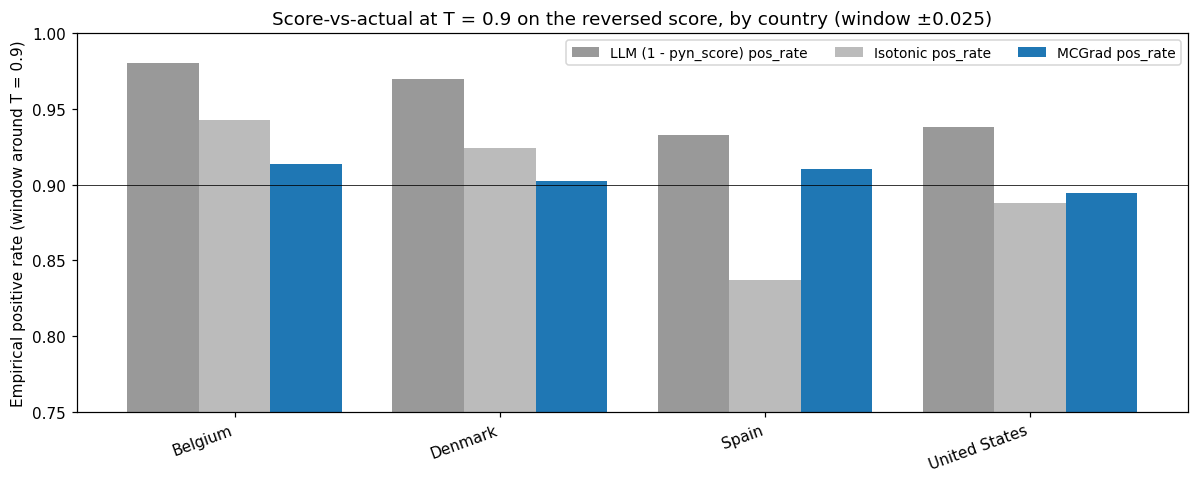

In [29]:
def plot_per_segment(df, segment_col, value_cols, ylabel, title,
                     ylim=None, axhline=None):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(len(df))
    width = 0.27
    for i, col in enumerate(value_cols):
        ax.bar(x + i * width, df[col], width, label=col, color=COLORS[i])
    if axhline is not None:
        ax.axhline(axhline, color='black', linewidth=0.5)
    ax.set_xticks(x + width)
    labels = df[segment_col].astype(str).str.replace('_', ' ')
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.legend(ncol=3, loc='best', fontsize=9)
    fig.tight_layout()
    plt.show()

plot_per_segment(
    mp_table, 'country', mp_cols,
    ylabel=f'Empirical positive rate (window around T = {T})',
    title=f'Score-vs-actual at T = {T} on the reversed score, by country (window ±{EPS})',
    ylim=(0.75, 1.0),
    axhline=T,
)

MCGrad's per-country empirical positive rate stays within ±1.5pp of T = 0.9 in every country, a 1.8pp spread sitting close to the dashed reference line. A 0.9 score really does mean ~90% in Belgium, Denmark, Spain, and the US. The raw LLM gives 93–98% at the same nominal 0.9 (over-confident, by an inconsistent amount), and isotonic gives 84–94% (closer on average, but with the widest per-country spread).

Why it matters operationally: imagine telling a stakeholder *"I'll auto-deprioritise any document the model is at least 90% confident is not about law/crime, and at most 10% of those will turn out to be law/crime cases I should have routed to a human."*

- Raw LLM: actual rate per country is 2% in Belgium, 3% in Denmark, 7% in Spain, 6% in the US (over-delivering, but inconsistently). Staffing, SLAs, and downstream cost-of-error all drift with traffic mix.

- Isotonic regression: global average closer, but per-country it spans 6–16%. Wider variance than raw in this case, since global calibration redistributes errors across segments rather than eliminating them per-segment.

- MCGrad: empirical rate sits within ±1.5pp of your promised 10% in every country. The same threshold means the same per-item commitment everywhere, no per-population tuning, no surprise drift when your traffic mix shifts.

(The calibration guarantee holds in expectation; finite samples wobble per-segment estimates around T by a few percentage points even with a perfectly multicalibrated model. MCGrad's per-segment band is much tighter than the alternatives, and centered on the threshold you set.)

### 5.2 Per-segment prevalence estimation

Multi-calibration also gives unbiased *averages* within any sub-population. Average a multi-calibrated score over a segment and you recover that segment's true positive rate. That's exactly what stakeholders want when they ask for per-country (or per-doc-type) breakdowns instead of the overall number.

We slice the test set by `country` and compute each estimator's per-segment prevalence. Bias = mean prediction − empirical positive rate.

In [30]:
score_map = {
    'LLM (pyn_score)': BASE_SCORE_COLUMN,
    'Isotonic':        IR_SCORE_COLUMN,
    'MCGrad':          MCGRAD_SCORE_COLUMN,
}

def per_segment_bias(df, segment_col, score_cols, label_col=LABEL_COLUMN):
    """Bias of each estimator within each value of segment_col."""
    rows = []
    for val, grp in df.groupby(segment_col):
        true_p = grp[label_col].mean()
        row = {segment_col: val, 'n': len(grp), 'true_pp': true_p * 100}
        for label, col in score_cols.items():
            row[label] = (grp[col].mean() - true_p) * 100
        rows.append(row)
    return pd.DataFrame(rows).sort_values(segment_col).reset_index(drop=True)

by_country = per_segment_bias(test_df, 'country', score_map)
by_country.style.format({**{k: '{:+.2f}p' for k in score_map}, 'true_pp': '{:.1f}%'})

,country,n,true_pp,LLM (pyn_score),Isotonic,MCGrad
0,Belgium,7920,10.0%,+5.07p,+2.16p,+0.34p
1,Denmark,4000,7.3%,+3.07p,-0.04p,-0.17p
2,Spain,8000,15.3%,+1.62p,-1.98p,-0.42p
3,United States,4000,4.8%,+3.03p,+0.19p,+0.30p


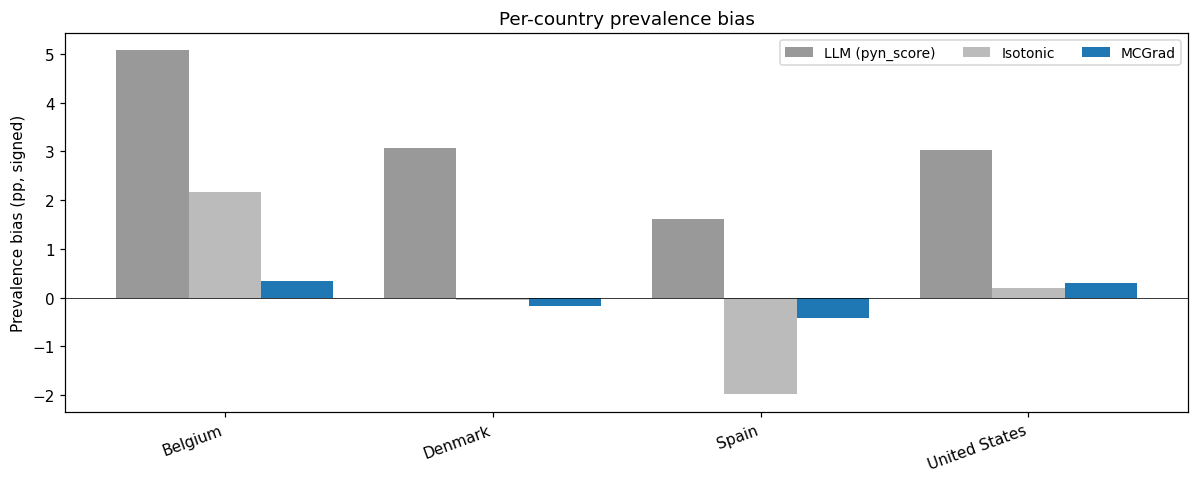

In [31]:
plot_per_segment(
    by_country, 'country', list(score_map.keys()),
    ylabel='Prevalence bias (pp, signed)',
    title='Per-country prevalence bias',
    axhline=0,
)

The raw LLM over-estimates in every country, with bias from +1.6 to +5.1pp. Isotonic regression pulls the average down but flips signs across countries (−2.0 to +2.2pp); a single global correction just rebalances per-segment bias instead of removing it. MCGrad keeps every country within ±0.5pp (range −0.42 to +0.34, spread 0.76pp), at or below sampling noise. The same model that cut global MCE σ from 22 to 4 also delivers accurate per-country prevalence, on top of the per-country risk guarantees on threshold-based decisions from §5.1.

## 6. Next Steps

You've now run the standard MCGrad workflow on an LLM classifier in the in-distribution setting. A few places to go next:

- [Methodology docs](https://mcgrad.dev/docs/methodology) for how MCGrad detects and corrects miscalibration internally.

- [API reference](https://mcgrad.readthedocs.io/) for constructor arguments, hyperparameter tuning, and model serialization for production.

- [MCGrad-for-measurement paper](https://github.com/facebookresearch/multicalibrated_llm_measurement) for theoretical results on why multicalibration is sufficient for unbiased prevalence estimation under covariate shift, plus a fuller experimental treatment.

- [Tutorial 01](01_mcgrad_core.ipynb) walks through the same workflow on a logistic regression base model if you want a non-LLM side-by-side reference.